# VHR Canopy Height Change Workflow Demo

#### `example topic`: multi-decadal vegetation structure change in the Arctic
This documents the notebooks, scripts, and steps associated with:  
+ finding candidate sites for assessing change
+ the use of `VHR Toolkit` for preparing $SR_{VHR}$ for the $CHM_{VHR}$ Workflow

Paul Montesano
Melanie Frost
Jordan Caraballo-Vega  
Matthew Macander   

Repositories:  
https://github.com/nasa-nccs-hpda/above-shrubs.git

`Main Components:`  
 - Document the processing steps on a selected catid from candidate site with a VHR time series  

`Motivations:`

 - Document the CHM modelling process the pre-processing of VHR used to run through the $CHM_{VHR}$ workflow ; use for a list of catids

`Notes:`  
 - need to ssh into ilab or forest VMs
 - /explore/nobackup/people/mmacande/srlite/chm_model/20231014_chm  


In [3]:
import os
import pandas as pd
import glob
import geopandas as gpd
import sys
sys.path.append('/home/pmontesa/code/evhr')
sys.path.append('/home/pmontesa/code/icesat2_boreal/lib')
import maplib_folium

import requests
import ipywidgets
import IPython.display
import contextily as ctx

## Read in candidate sites database with t1 and t2 imagery
(from `prep_candidate_sites_ipynb`)

In [27]:
dir_prj_pmm = '/explore/nobackup/people/pmontesa/userfs02/projects/ilab/above_shrubs'
MAINDIR = '/explore/nobackup/projects/above/misc/ABoVE_Shrubs'

In [28]:
candidate_sites_t1_t2 = gpd.read_file(f'{dir_prj_pmm}/data/arc/candidate_sites_t1t2_db.gpkg')
candidate_sites = gpd.read_file(os.path.join(MAINDIR, 'footprints','footprints_candidate_sites.gpkg'))

<Axes: >

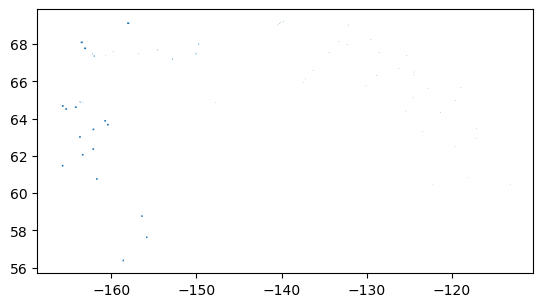

In [29]:
candidate_sites.plot()

### Summarize year delta for candidate sites

In [7]:
def plot_hist_cmap(data, n_bars, cmapname='plasma', title=''):
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.pyplot import figure

    figure(figsize=(10, 2), dpi=80)

    # This is  the colormap I'd like to use.
    cm = plt.cm.get_cmap(cmapname)

    # Get the histogramp
    Y,X = np.histogram(data, n_bars)
    x_span = X.max()-X.min()
    C = [cm(((x-X.min())/x_span)) for x in X]

    plt.bar(X[:-1],Y,color=C,width=X[1]-X[0])
    plt.title(title)
    plt.show()

In [10]:
candidate_sites_t1_t2_smry = candidate_sites_t1_t2.groupby(['name', candidate_sites_t1_t2['geometry'].to_wkt()]).agg(#name=('name','sum'),
                                                                                                             cnt_t1=('catid_left', pd.Series.nunique), 
                                                                                                             cnt_t2=('catid_right', pd.Series.nunique), 
                                                                                                             cnt_year_delta=('year_delta', pd.Series.nunique), 
                                                                                                             min_year_delta=('year_delta', 'min'),
                                                                                                             max_year_delta=('year_delta', 'max')
                                                                                                            ).reset_index()#.rename(columns={'index': 'geometry'})

candidate_sites_t1_t2_smry.columns = ['name','geometry','cnt_t1','cnt_t2','cnt_year_delta','min_year_delta','max_year_delta']
candidate_sites_t1_t2_smry['geometry'] = gpd.GeoSeries.from_wkt(candidate_sites_t1_t2_smry['geometry'], crs=4326)
candidate_sites_t1_t2_smry = gpd.GeoDataFrame(candidate_sites_t1_t2_smry)

In [17]:
candidate_sites_t1_t2_smry[candidate_sites_t1_t2_smry.tail()

,name,geometry,cnt_t1,cnt_t2,cnt_year_delta,min_year_delta,max_year_delta
21,seward_C9_forestold01,"POLYGON ((-163.30292 64.88203, -163.35765 64.8...",2,4,5,17.0,23.0
22,seward_CE_woodland01,"POLYGON ((-163.69385 64.91179, -163.74845 64.8...",2,5,4,16.0,22.0
23,sewardfloodplain01,"POLYGON ((-163.63437 64.86556, -163.68889 64.8...",2,6,4,16.0,22.0
24,sewardriparian01,"POLYGON ((-163.60471 64.84244, -163.6592 64.82...",2,6,4,16.0,22.0
25,tuklantzb01,"POLYGON ((-132.1096 69.00915, -132.18429 69.01...",1,0,0,NaN,NaN


/explore/nobackup/people/pmontesa/.nccstmp/ipykernel_931223/3177371190.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap(cmapname)


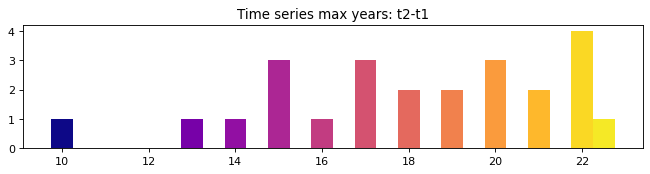

In [22]:
n_bars = 2*int(candidate_sites_t1_t2_smry.max_year_delta.max()-candidate_sites_t1_t2_smry.max_year_delta.min())
plot_hist_cmap(candidate_sites_t1_t2_smry[~candidate_sites_t1_t2_smry.max_year_delta.isna()].max_year_delta, n_bars, 
               cmapname='plasma', title='Time series max years: t2-t1')

In [23]:
candidate_sites_t1_t2_smry.explore(column='max_year_delta', cmap='plasma', width=1000, height=300)

These `candidate sites` all feature a 'time-series' of VHR in and near forest-tundra transition zones in Alaska and NW Canada.  
The histogram above suggest many options for specific time-series (pairs of `old` and `new` catids).  
Will need to high grade based on cloud-cover.

In [24]:
candidate_sites_t1_t2_smry.shape

(26, 7)

# Document processing steps on a selected catid from candidate site with a VHR time series 

## Choose a catalog id: $catalogID_{MAXAR}$

In [25]:
# Find the sites with max time series
candidate_sites_t1_t2[candidate_sites_t1_t2.year_delta == candidate_sites_t1_t2_smry.max_year_delta.max()][['name','catid_left','year_left','catid_right','year_right']]

,name,catid_left,year_left,catid_right,year_right
650,seward_C9_forestold01,2000070622201840000010022655,2000,105001003537F700,2023


In [31]:
candidate_sites[candidate_sites.name == 'sewardriparian01']

,name,file,area_km2,area_ha,geometry
57,sewardriparian01,arcticDEM_sewardriparian01_10m_mf300_LCunmaske...,9.0,900.0,"POLYGON ((-163.60471 64.84243, -163.65920 64.8..."


In [32]:
candidate_sites_t2 = gpd.sjoin(candidate_sites, vhr_gdf_selection_new.drop(COLS_DROP, axis=1), op='intersects', how='left').dropna(subset=['sensor'])
#candidate_sites_t2[candidate_sites_t2.name == 'sewardriparian01']
vhr_gdf_selection_new[vhr_gdf_selection_new.catid == '1040010078426800']

/panfs/ccds02/app/modules/jupyter/ilab/pytorch-kernel-042424/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3517: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if await self.run_code(code, result, async_=asy):


,geometry,catid,sensor,acq_year,acq_month,year,cloudcover,avsunazim,min_added_date,max_added_date,name_left,file_left,area_km2_left,area_ha_left,index_right,name_right,file_right,area_km2_right,area_ha_right
23341,"POLYGON ((-163.47888 64.48810, -163.79950 64.4...",1040010078426800,WV03,2022,6,2022,0.0,173.19507,2022-06-20 00:00:00+00:00,2022-06-20 00:00:00+00:00,sewardriparian01,arcticDEM_sewardriparian01_10m_mf300_LCunmaske...,9.0,900.0,57,sewardriparian01,arcticDEM_sewardriparian01_10m_mf300_LCunmaske...,9.0,900.0
23341,"POLYGON ((-163.47888 64.48810, -163.79950 64.4...",1040010078426800,WV03,2022,6,2022,0.0,173.19507,2022-06-20 00:00:00+00:00,2022-06-20 00:00:00+00:00,sewardriparian01,arcticDEM_sewardriparian01_10m_mf300_LCunmaske...,9.0,900.0,56,sewardfloodplain01,arcticDEM_sewardfloodplain01_10m_mf300_LCunmas...,9.0,900.0
23341,"POLYGON ((-163.47888 64.48810, -163.79950 64.4...",1040010078426800,WV03,2022,6,2022,0.0,173.19507,2022-06-20 00:00:00+00:00,2022-06-20 00:00:00+00:00,sewardriparian01,arcticDEM_sewardriparian01_10m_mf300_LCunmaske...,9.0,900.0,53,seward_C1_forestnew01,arcticDEM_seward_C1_forestnew01_10m_mf300_LCun...,9.0,900.0
23341,"POLYGON ((-163.47888 64.48810, -163.79950 64.4...",1040010078426800,WV03,2022,6,2022,0.0,173.19507,2022-06-20 00:00:00+00:00,2022-06-20 00:00:00+00:00,sewardriparian01,arcticDEM_sewardriparian01_10m_mf300_LCunmaske...,9.0,900.0,55,seward_CE_woodland01,arcticDEM_seward_CE_woodland01_10m_mf300_LCunm...,9.0,900.0
23341,"POLYGON ((-163.47888 64.48810, -163.79950 64.4...",1040010078426800,WV03,2022,6,2022,0.0,173.19507,2022-06-20 00:00:00+00:00,2022-06-20 00:00:00+00:00,sewardfloodplain01,arcticDEM_sewardfloodplain01_10m_mf300_LCunmas...,9.0,900.0,57,sewardriparian01,arcticDEM_sewardriparian01_10m_mf300_LCunmaske...,9.0,900.0
23341,"POLYGON ((-163.47888 64.48810, -163.79950 64.4...",1040010078426800,WV03,2022,6,2022,0.0,173.19507,2022-06-20 00:00:00+00:00,2022-06-20 00:00:00+00:00,sewardfloodplain01,arcticDEM_sewardfloodplain01_10m_mf300_LCunmas...,9.0,900.0,56,sewardfloodplain01,arcticDEM_sewardfloodplain01_10m_mf300_LCunmas...,9.0,900.0
23341,"POLYGON ((-163.47888 64.48810, -163.79950 64.4...",1040010078426800,WV03,2022,6,2022,0.0,173.19507,2022-06-20 00:00:00+00:00,2022-06-20 00:00:00+00:00,sewardfloodplain01,arcticDEM_sewardfloodplain01_10m_mf300_LCunmas...,9.0,900.0,53,seward_C1_forestnew01,arcticDEM_seward_C1_forestnew01_10m_mf300_LCun...,9.0,900.0
23341,"POLYGON ((-163.47888 64.48810, -163.79950 64.4...",1040010078426800,WV03,2022,6,2022,0.0,173.19507,2022-06-20 00:00:00+00:00,2022-06-20 00:00:00+00:00,sewardfloodplain01,arcticDEM_sewardfloodplain01_10m_mf300_LCunmas...,9.0,900.0,55,seward_CE_woodland01,arcticDEM_seward_CE_woodland01_10m_mf300_LCunm...,9.0,900.0
23341,"POLYGON ((-163.47888 64.48810, -163.79950 64.4...",1040010078426800,WV03,2022,6,2022,0.0,173.19507,2022-06-20 00:00:00+00:00,2022-06-20 00:00:00+00:00,seward_C1_forestnew01,arcticDEM_seward_C1_forestnew01_10m_mf300_LCun...,9.0,900.0,57,sewardriparian01,arcticDEM_sewardriparian01_10m_mf300_LCunmaske...,9.0,900.0
23341,"POLYGON ((-163.47888 64.48810, -163.79950 64.4...",1040010078426800,WV03,2022,6,2022,0.0,173.19507,2022-06-20 00:00:00+00:00,2022-06-20 00:00:00+00:00,seward_C1_forestnew01,arcticDEM_seward_C1_forestnew01_10m_mf300_LCun...,9.0,900.0,56,sewardfloodplain01,arcticDEM_sewardfloodplain01_10m_mf300_LCunmas...,9.0,900.0


### Check the image thumbnail from MAXAR

In [33]:
CATID = '10300100EA10A300'
ipywidgets.Image(value=requests.get(f'https://api.discover.digitalglobe.com/show?id={CATID}').content, format='png',width='10%',height='10%')

Image(value=b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x08\x06\x0…

In [34]:
FOCAL_SITENAME = 'sewardriparian01' #'Creamer_823_1_49'

In [35]:
FOCAL_SITE_GDF = candidate_sites_t1[candidate_sites_t1.name == FOCAL_SITENAME]

In [36]:
FOCAL_SITE_GDF_smry = FOCAL_SITE_GDF.groupby(['name','catid','sensor','acq_month','year']).agg(cnt_catid=('catid', pd.Series.nunique)).reset_index()
FOCAL_SITE_GDF_smry

,name,catid,sensor,acq_month,year,cnt_catid
0,sewardriparian01,10100100024B6600,QB02,9.0,2003,1
1,sewardriparian01,10100100024CEA00,QB02,9.0,2003,1
2,sewardriparian01,101001000457A300,QB02,6.0,2005,1
3,sewardriparian01,2000060822003210000010004708,IK01,6.0,2000,1
4,sewardriparian01,2000060822004260000010004709,IK01,6.0,2000,1
5,sewardriparian01,2000062822281570000010017021,IK01,6.0,2000,1
6,sewardriparian01,2000063022025770000010018472,IK01,6.0,2000,1
7,sewardriparian01,2001060322302300000010031883,IK01,6.0,2001,1
8,sewardriparian01,2001070622333420000010025793,IK01,7.0,2001,1
9,sewardriparian01,2003080322560250000010019501,IK01,8.0,2003,1


In [ ]:
CATID_LIST = []
CATID_BROWSE_IMG_LIST = []
CATID_BROWSE_DICT_LIST = []

for index,row in FOCAL_SITE_GDF_smry.iterrows():
    
    CATID = row['catid']   
    browse_img = ipywidgets.Image(value=requests.get(f'https://api.discover.digitalglobe.com/show?id={CATID}').content, format='png',width='10%',height='10%')
    CATID_BROWSE_IMG_LIST.append(browse_img)
    CATID_BROWSE_DICT = {'sensor': row['sensor'],
                         'catid':  CATID, 
                         'year':   row['year'],
                         'month':  row['acq_month'],
                         #'browse_img_list': CATID_BROWSE_IMG_LIST,
                         'browse_img': browse_img
                        }
    
    CATID_BROWSE_DICT_LIST.append(CATID_BROWSE_DICT)

### View browse image of $catalogID_{MAXAR}$
`IKONOS` wont have thumbnails

In [37]:
sidebyside = ipywidgets.HBox(CATID_BROWSE_IMG_LIST)
IPython.display.display(sidebyside, display_id=CATID_BROWSE_DICT['catid'])

NameError: name 'CATID_BROWSE_IMG_LIST' is not defined

## Get list of scenes: query NASA NGA database of MAXAR $M1BS_{VHR}$ imagery
this creates `SCENES_FILE` : a list the input $M1BS_{VHR}$ scenes found for a $catalogID_{MAXAR}$ in our NASA NGA dataBase archive into a local dir of choice in preparation for workflow processing
#### `query_db_catid` works with `forest` conda env which has `psycopg2`
Resources:  
 - code/geoscitools/query_ngadb.ipynb
 - Catalog IDs of interest:
   - Western AK (July,August): https://docs.google.com/spreadsheets/d/1XdSTInm18KYBUvaftyev449GwhMKZzWjl3uV1gUF-yI/edit#gid=288708282
   - Western AK (July,August), Sun Elev > 17: https://docs.google.com/spreadsheets/d/1ig4YQu1dG-2pWWbl6ZRxz37ebERsX80bLcEZLIdKqtQ/edit#gid=1404456155

In [38]:
# TODO - get this right. 
# The expected ENV variables arent accessible for some reason
#
#  NGA DB password doesnt appear when printed here, but it does in terminal
#!env | grep NGADBPASS
#!source /home/pmontesa/.bashrc
#os.environ['NGADBPASS']

In [4]:
!pip install psycopg2

Defaulting to user installation because normal site-packages is not writeable


In [ ]:
import os, sys
sys.path.append('/home/pmontesa/code/evhr')
import query_db_catid

In [ ]:
MAINDIR = '/explore/nobackup/projects/above/misc/ABoVE_Shrubs'

### Get NGA dB password

Also, type this at terminal and copy result:  
env | grep NGADBPASS  

In [7]:
# To make this work you need to source the bashrc in scope with the sh script
returned_list = !source ~/.bashrc ; source ~/get_ngadb_pass.sh
NGADBPASS = returned_list[0]

In [8]:
OUTDIR_QUERY = os.path.join(MAINDIR, 'query_nga_db')
!mkdir -p $OUTDIR_QUERY

In [9]:
# Wrappers of query
def GET_NGA_CATID_SCENE_SYMLINKS(CATID, OUTDIR_QUERY):
    OUTDIR_CATID = os.path.join(OUTDIR_QUERY, CATID)
    !mkdir -p $OUTDIR_CATID
    query_db_catid.query_db_catid_v2(CATID, 'M1BS', OUTDIR_CATID, None,'pmontesa', NGADBPASS, symlink=True)
    return OUTDIR_CATID

def GET_NGA_CATID_SCENE_LIST(CATID, OUTDIR_QUERY):
    OUT_SCENE_LIST_FN = os.path.join(OUTDIR_QUERY, CATID + '_scenes.csv')
    
    query_db_catid.query_db_catid_v2(CATID, 'M1BS', OUTDIR_QUERY, OUT_SCENE_LIST_FN,'pmontesa', NGADBPASS, symlink=False)
    return OUT_SCENE_LIST_FN

In [10]:
# Test with QB2 catid
SCENES_FILE = GET_NGA_CATID_SCENE_LIST('10100100024B6600', OUTDIR_QUERY)
SCENES_FILE


	 Now executing database query on catID '10100100024B6600' ...

	 Found '2' scenes for catID '10100100024B6600' 

	 List of all prod_id '['052800768010']'
	 Selecting data associated with prod_id '052800768010'
/css/nga/QB02/1B/2003/260/QB02_10100100024B6600_X1BS_052800768010_01/QB02_20030917220820_10100100024B6600_03SEP17220820-M1BS-052800768010_01_P002.ntf
/css/nga/QB02/1B/2003/260/QB02_10100100024B6600_X1BS_052800768010_01/QB02_20030917220816_10100100024B6600_03SEP17220816-M1BS-052800768010_01_P001.ntf


'/explore/nobackup/projects/above/misc/ABoVE_Shrubs/query_nga_db/10100100024B6600_scenes.csv'

In [11]:
# Test with IKONOS catid
SCENES_FILE = GET_NGA_CATID_SCENE_LIST('2000060822003210000010004708', OUTDIR_QUERY)
SCENES_FILE


	 Now executing database query on catID '2000060822003210000010004708' ...

	 Found '4' scenes for catID '2000060822003210000010004708' 

	 List of all prod_id '['/css/nga/IK01']'
	 Selecting data associated with prod_id '/css/nga/IK01'
/css/nga/IK01_IK/2A/2000/160/IK01_2000060822003210000010004708_X2AS_946589/IK01_20000608220000_2000060822003210000010004708_po_946589_grn_0000000.ntf
/css/nga/IK01_IK/2A/2000/160/IK01_2000060822003210000010004708_X2AS_946589/IK01_20000608220000_2000060822003210000010004708_po_946589_blu_0000000.ntf
/css/nga/IK01_IK/2A/2000/160/IK01_2000060822003210000010004708_X2AS_946589/IK01_20000608220000_2000060822003210000010004708_po_946589_nir_0000000.ntf
/css/nga/IK01_IK/2A/2000/160/IK01_2000060822003210000010004708_X2AS_946589/IK01_20000608220000_2000060822003210000010004708_po_946589_red_0000000.ntf


'/explore/nobackup/projects/above/misc/ABoVE_Shrubs/query_nga_db/2000060822003210000010004708_scenes.csv'

In [ ]:
SCENES_FILE = GET_NGA_CATID_SCENE_LIST('2001070612501380000011625792', OUTDIR_QUERY)
SCENES_FILE

## $TOA_{VHR}$ Processing 
with eVHR tool  
this produces $TOA_{VHR}$, an orthorectified top-of-atmosphere reflectance image of the multi-spectral bands of the original $M1BS_{VHR}$ input

In [1]:
CATID = '2000060822003210000010004708'

In [2]:
OUTDIR_TOA = os.path.join(MAINDIR, 'toa_tmp','002m')
!mkdir -p $OUTDIR_TOA
OUTDIR_TOA

NameError: name 'os' is not defined

#### $TOA_{VHR}$: confirm output exists after run

In [45]:
SEARCH_TOA = os.path.join(OUTDIR_TOA, f'**/*{CATID}*toa.tif')
SEARCH_TOA

'/explore/nobackup/projects/above/misc/ABoVE_Shrubs/toa_tmp/002m/**/*10100100024B6600*toa.tif'

In [46]:
glob.glob(SEARCH_TOA)

[]

#### Get command
process on `ilab` VM

In [27]:
SCENES_FILE = '/explore/nobackup/projects/above/misc/ABoVE_Shrubs/query_nga_db/2000060822003210000010004708_scenes.csv'

In [28]:
!echo \
singularity exec -B /explore,/panfs,/css,/nfs4m \
/explore/nobackup/people/iluser/ilab_containers/evhr_4.0.0.sif \
python /usr/local/ilab/evhr/view/evhrToaCLV.py \
-o $OUTDIR_TOA \
--scenes_in_file $SCENES_FILE

singularity exec -B /explore,/panfs,/css,/nfs4m /explore/nobackup/people/iluser/ilab_containers/evhr_4.0.0.sif python /usr/local/ilab/evhr/view/evhrToaCLV.py -o /explore/nobackup/projects/above/misc/ABoVE_Shrubs/toa_tmp/002m --scenes_in_file /explore/nobackup/projects/above/misc/ABoVE_Shrubs/query_nga_db/2000060822003210000010004708_scenes.csv


For `IKONOS`, eVHR TOA will fail - there is no `.xml` file.  
The metadata file is like this: `/css/nga/IK01_IK/2A/2000/160/IK01_2000060822003210000010004708_X2AS_946589/IK01_20000608220000_2000060822003210000010004708_po_946589_metadata.txt`

## $TOA_{VHR Cloudmask}$ Processing
process on `ilab` VM  
this produces a $Cloudmask_{VHR}$ from the input $TOA_{VHR}$  
https://nasa-nccs-hpda.github.io/vhr-cloudmask/latest/readme.html#development-pipeline-details

In [31]:
OUTDIR_CLOUD = os.path.join(MAINDIR, 'cloudmask_tmp','002m')
!mkdir -p $OUTDIR_CLOUD

In [22]:
TOA_FN_LIST = glob.glob(SEARCH_TOA)
TOA_FN_LIST

['/explore/nobackup/projects/above/misc/ABoVE_Shrubs/toa_tmp/002m/5-toas/QB02_20020710_M1BS_1010010000C41400-toa.tif']

#### Get command
login to `ilab201-210` or `forest201-210`

In [32]:
!echo -o $OUTDIR_CLOUD -r $SEARCH_TOA -s predict

-o /explore/nobackup/projects/above/misc/ABoVE_Shrubs/cloudmask_tmp/002m -r /explore/nobackup/projects/above/misc/ABoVE_Shrubs/toa_tmp/002m/5-toas/QB02_20020710_M1BS_1010010000C41400-toa.tif -s predict


In [39]:
!echo \
singularity exec --nv -B /explore/nobackup/people,/explore/nobackup/projects \
/explore/nobackup/projects/ilab/containers/vhr-cloudmask.sif vhr-cloudmask-cli \
-o $OUTDIR_CLOUD \
-r $SEARCH_TOA \
-s predict

singularity exec --nv -B /explore/nobackup/people,/explore/nobackup/projects /explore/nobackup/projects/ilab/containers/vhr-cloudmask.sif vhr-cloudmask-cli -o /explore/nobackup/projects/above/misc/ABoVE_Shrubs/cloudmask_tmp/002m -r /explore/nobackup/projects/above/misc/ABoVE_Shrubs/toa_tmp/002m/5-toas/QB02_20020710_M1BS_1010010000C41400-toa.tif -s predict


#### $Cloudmask_{VHR}$: confirm output exists after run

## $SR_{VHR}$ Processing
process on `ilab` VM  
this produces a $SR_{VHR}$ that is modeled from input $TOA_{VHR}$ and $SR_{reference}$

In [48]:
OUTDIR_SR = os.path.join(MAINDIR, 'srlite_tmp','002m')
OUTPUT_SR_CATID_INFO_FN = os.path.join(OUTDIR_SR, f'{CATID}.out')
OUTPUT_SR_CATID_INFO_FN

'/explore/nobackup/projects/above/misc/ABoVE_Shrubs/srlite_tmp/002m/10100100024B6600.out'

In [49]:
OUTDIR_CCDC = os.path.join(MAINDIR, 'ccdc','030m')
SEARCH_CCDC = os.path.join(OUTDIR_CCDC, f'*{CATID}*.tif')
SEARCH_CCDC

'/explore/nobackup/projects/above/misc/ABoVE_Shrubs/ccdc/030m/*10100100024B6600*.tif'

#### $SR_{reference}$: confirm the reference SR data exists (using CCDC as reference)
this $SR_{reference}$ data along with $TOA_{VHR}$ is required to model $SR_{VHR}$

In [113]:
glob.glob(SEARCH_CCDC)

[]

In [50]:
!echo \
singularity run -B /explore,/panfs \
/explore/nobackup/people/iluser/ilab_containers/srlite_1.1.0.sif \
python /usr/local/ilab/srlite/view/SrliteWorkflowCommandLineView.py \
-toa_dir $OUTDIR_TOA \
-target_dir $OUTDIR_CCDC \
-cloudmask_dir $OUTDIR_CLOUD \
-bandpairs "[['blue_ccdc', 'BAND-B'], ['green_ccdc', 'BAND-G'], ['red_ccdc', 'BAND-R'], ['nir_ccdc', 'BAND-N'],['blue_ccdc', 'BAND-C'], ['green_ccdc', 'BAND-Y'], ['red_ccdc', 'BAND-RE'], ['nir_ccdc', 'BAND-N2']]" \
-output_dir $OUTDIR_SR \
--regressor rma --debug 1 --pmask --cloudmask --csv --band8 \
--cloudmask_suffix toa.cloudmask.tif --target_suffix ccdc.tif \
2>&1 | tee -a $OUTPUT_SR_CATID_INFO_FN


singularity run -B /explore,/panfs /explore/nobackup/people/iluser/ilab_containers/srlite_1.1.0.sif python /usr/local/ilab/srlite/view/SrliteWorkflowCommandLineView.py -toa_dir -target_dir -cloudmask_dir -bandpairs [['blue_ccdc', 'BAND-B'], ['green_ccdc', 'BAND-G'], ['red_ccdc', 'BAND-R'], ['nir_ccdc', 'BAND-N'],['blue_ccdc', 'BAND-C'], ['green_ccdc', 'BAND-Y'], ['red_ccdc', 'BAND-RE'], ['nir_ccdc', 'BAND-N2']] -output_dir --regressor rma --debug 1 --pmask --cloudmask --csv --band8 --cloudmask_suffix toa.cloudmask.tif --target_suffix ccdc.tif


## Footprint

In [10]:
sys.path.append('/home/pmontesa/code/geoscitools')
import footprintlib

## Plot multi-band image

In [11]:
import rasterio
from rasterio.plot import show_hist, show
import numpy as np
import matplotlib.pyplot as plt

In [12]:
def rescale_pct_clip(array, pct=[1,80]):
    '''Re-scales data values of an array from 0-1 with percentiles'''
    array_min, array_max = np.nanpercentile(array,pct[0]), np.nanpercentile(array,pct[1])
    clip = (array - array_min) / (array_max - array_min)
    clip[clip>1]=1
    clip[clip<0]=0
    return clip

def rescale_multiband_for_plot(fn, rescaled_multiband_fn, bandlist = [4,3,2], pct=[5,95], nodata=-9999.0):
    
    # add a reduced res: https://gis.stackexchange.com/questions/434441/specifying-target-resolution-when-resampling-with-rasterio
    
    with rasterio.open(fn, "r+") as src1:
        
        src1.nodata = nodata
        arr_list = []
        for band in bandlist:
            arr = src1.read(band)
            arr_list.append(arr)
            
        with rasterio.open(rescaled_multiband_fn, 'w+',
                driver='GTiff',
                dtype= rasterio.float32,
                count=3,
                crs = src1.crs,
                width=src1.width,
                height=src1.height,
                transform=src1.transform,
                nodata=src1.nodata

            ) as dst:

            for i, band in enumerate(bandlist): 
                V = rescale_pct_clip(src1.read(band), pct=pct)
                dst.write(V,i+1)
            

In [17]:
fn = '/explore/nobackup/projects/above/misc/ABoVE_Shrubs/toa_tmp/002m/5-toas/QB02_20020710_M1BS_1010010000C41400-toa.tif'
fn = '/explore/nobackup/projects/ilab/data/srlite/toa/Whitesands/QB02_20020914_M1BS_10100100012C3E00-toa.tif'
#fn = '/explore/nobackup/projects/ilab/data/srlite/toa/Whitesands/WV02_20130812_M1BS_1030010025689900-toa.tif'

outdir = os.path.dirname(fn)
rescaled_multiband_fn = os.path.join(outdir, 'multi_band_temp.tif')
rescale_multiband_for_plot(fn, rescaled_multiband_fn, pct=[25,85], nodata=-9999.0) 

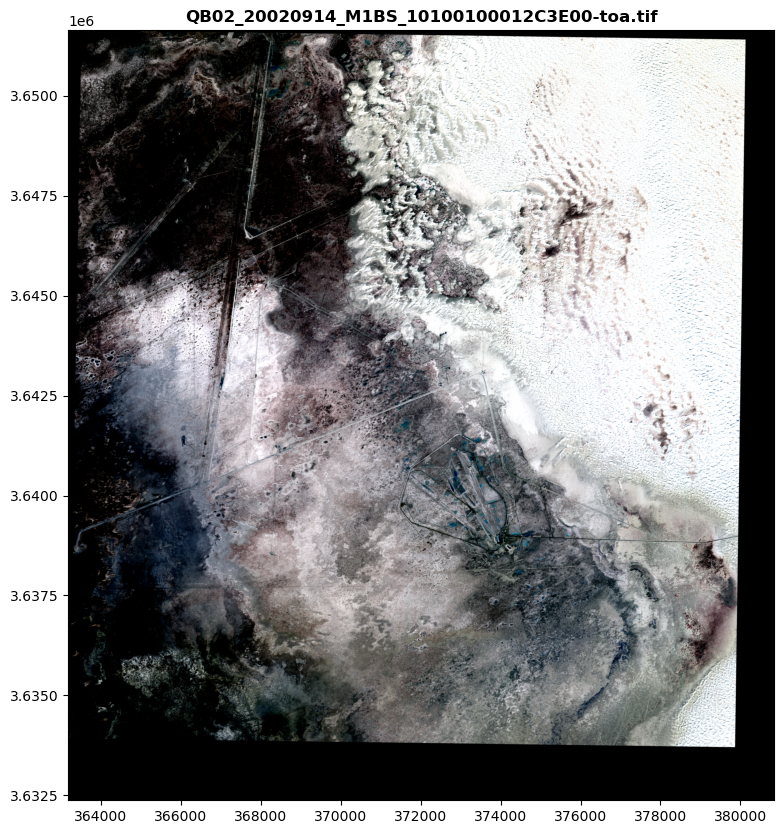

In [18]:
fig,ax=plt.subplots(figsize=(10,10))
with rasterio.open(rescaled_multiband_fn) as src:
    show(src.read(),transform=src.transform, ax=ax, title=os.path.basename(fn))
    #bounds  = src.bounds